In [271]:
import os
import pandas as pd
import numpy as np
import yaml

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps as cm
from scipy import stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from statsmodels.tsa.stattools import adfuller

In [185]:
assert os.path.exists("../../data/Ca phe")

In [186]:
set3_colors = [cm.get_cmap("Set1")(i / 9) for i in range(9)]
set3_colors

[(np.float64(0.8941176470588236),
  np.float64(0.10196078431372549),
  np.float64(0.10980392156862745),
  np.float64(1.0)),
 (np.float64(0.21568627450980393),
  np.float64(0.49411764705882355),
  np.float64(0.7215686274509804),
  np.float64(1.0)),
 (np.float64(0.30196078431372547),
  np.float64(0.6862745098039216),
  np.float64(0.2901960784313726),
  np.float64(1.0)),
 (np.float64(0.596078431372549),
  np.float64(0.3058823529411765),
  np.float64(0.6392156862745098),
  np.float64(1.0)),
 (np.float64(1.0),
  np.float64(0.4980392156862745),
  np.float64(0.0),
  np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(0.2), np.float64(1.0)),
 (np.float64(0.6509803921568628),
  np.float64(0.33725490196078434),
  np.float64(0.1568627450980392),
  np.float64(1.0)),
 (np.float64(0.9686274509803922),
  np.float64(0.5058823529411764),
  np.float64(0.7490196078431373),
  np.float64(1.0)),
 (np.float64(0.6), np.float64(0.6), np.float64(0.6), np.float64(1.0))]

# Cà phê

In [187]:
caphe_df = pd.read_html("../../data/Ca phe")[0]
caphe_df["Ngày"] = pd.to_datetime(caphe_df["Ngày"])

C:\Users\Asriel\AppData\Local\Temp\ipykernel_5940\1114143048.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  caphe_df["Ngày"] = pd.to_datetime(caphe_df["Ngày"])


In [188]:
caphe_df.head()

,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Ngày,Giá
0,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,2025-05-09,128233.0
1,Cà phê Robusta nhân xô,Đắk Nông,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,2025-05-09,128350.0
2,Cà phê Robusta nhân xô,Gia Lai,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,2025-05-09,128233.0
3,Cà phê Robusta nhân xô,Kon Tum,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,2025-05-09,128200.0
4,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,Vnđ/Kg,VNĐ,CTV địa phương,2025-05-09,128000.0


## Các sản phẩm

In [189]:
caphe_df["Tên_mặt_hàng"].unique()

array(['Cà phê Robusta nhân xô', 'Cà phê Arabica nhân xô'], dtype=object)

# Kiểm tra dữ liệu thừa

In [190]:
caphe_df.duplicated().sum()

np.int64(0)

## Kiểm tra dữ liệu thiếu

In [191]:
caphe_df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

## Trực quan giá sản phẩm

In [192]:
caphe_df_sorted = caphe_df.sort_values("Ngày")

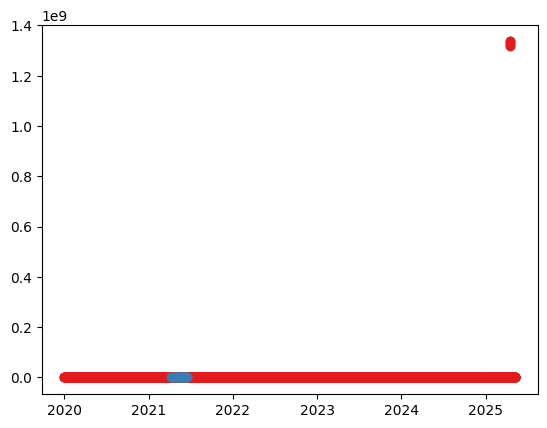

In [193]:
caphe_items = caphe_df["Tên_mặt_hàng"].unique()

for idx, item in enumerate(caphe_items):
    item_df = caphe_df_sorted[caphe_df_sorted["Tên_mặt_hàng"] == item]

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=set3_colors[idx%9])

## Lúa gạo

In [194]:
luagao_df = pd.read_html("../../data/Lua, gao")[0]
luagao_df["Ngày"] = pd.to_datetime(luagao_df["Ngày"])
luagao_df.head()

C:\Users\Asriel\AppData\Local\Temp\ipykernel_5940\1264372066.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  luagao_df["Ngày"] = pd.to_datetime(luagao_df["Ngày"])


,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Ngày,Giá
0,CLC 4900,Cần Thơ,Thương lái thu mua,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,16000.00
1,IR 5451,Cần Thơ,Thương lái thu mua,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,7000.00
2,Jasmine,Cần Thơ,Thương lái thu mua,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,11266.67
3,OM 18,Cần Thơ,Thương lái thu mua,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,7000.00
4,OM 5451,Cần Thơ,Thương lái thu mua,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,6000.00


## Các sản phẩm

In [195]:
luagao_items = luagao_df["Tên_mặt_hàng"].unique()
luagao_items[:10]

array(['CLC 4900', 'IR 5451', 'Jasmine', 'OM 18', 'OM 5451', 'ST25',
       'Đài Thơm 8', 'Gạo thường', 'Gạo 15% tấm', 'Gạo 25% tấm'],
      dtype=object)

# Kiểm tra dữ liệu thiếu

In [196]:
luagao_df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

## Kiểm tra dữ liệu thừa

In [197]:
luagao_df.duplicated().sum()

np.int64(3)

In [198]:
luagao_df = luagao_df.drop_duplicates()

In [199]:
luagao_df.duplicated().sum()

np.int64(0)

## Trực quan giá sản phẩm

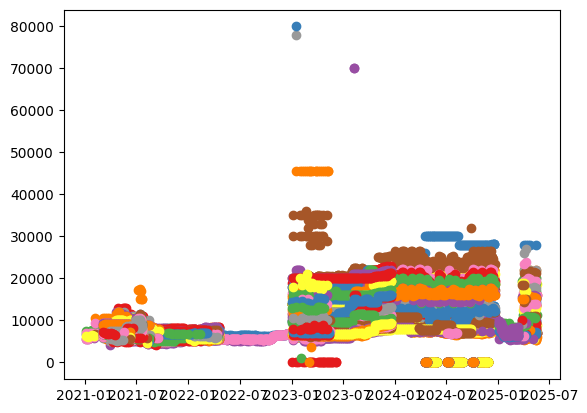

In [200]:
for idx, item in enumerate(luagao_items):
    item_df = luagao_df[luagao_df["Tên_mặt_hàng"] == item]
    item_df = item_df.sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=set3_colors[idx%9])

# Rau, quả

In [201]:
rauqua_df = pd.read_html("../../data/Rau, qua")[0]
rauqua_df["Ngày"] = pd.to_datetime(rauqua_df["Ngày"])
rauqua_df.head()

C:\Users\Asriel\AppData\Local\Temp\ipykernel_5940\762311435.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rauqua_df["Ngày"] = pd.to_datetime(rauqua_df["Ngày"])


,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Ngày,Giá
0,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,10000.0
1,Bắp cải thảo,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,10000.0
2,Bưởi da xanh,Sơn La,Bán lẻ,VNĐ/quả,VNĐ,CTV địa phương,2025-05-19,35000.0
3,Bưởi Diễn,Sơn La,Bán lẻ,VNĐ/quả,VNĐ,CTV địa phương,2025-05-19,10000.0
4,Cà chua,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,2025-05-19,12000.0


## Các sản phẩm

In [202]:
rauqua_items = rauqua_df["Tên_mặt_hàng"].unique()
rauqua_items[:10]

array(['Bắp cải', 'Bắp cải thảo', 'Bưởi da xanh', 'Bưởi Diễn', 'Cà chua',
       'Cà rốt', 'Chanh', 'Củ cải', 'Đào', 'Đậu cove'], dtype=object)

## Kiểm tra dữ liệu thiếu

In [203]:
rauqua_df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

## Kiểm tra dữ liệu thừa

In [204]:
rauqua_df.duplicated().sum()

np.int64(0)

## Kiểm tra dữ liệu thiếu

In [205]:
rauqua_df.isnull().sum()

Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Ngày            0
Giá             0
dtype: int64

## Trực quan giá sản phẩm

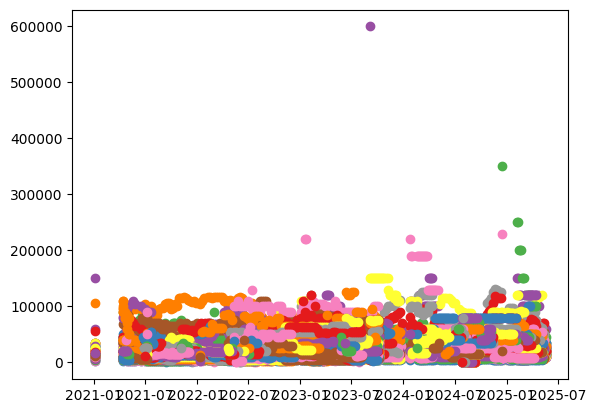

In [206]:
for idx, item in enumerate(rauqua_items):
    item_df = rauqua_df[rauqua_df["Tên_mặt_hàng"] == item]
    item_df = item_df.sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=set3_colors[idx%9])

# Gộp bảng

## Fill các ngày từ min -> max

In [207]:
date_min = np.min([
    caphe_df["Ngày"].min(), 
    luagao_df["Ngày"].min(), 
    caphe_df["Ngày"].min()
])
date_max = np.max([
    caphe_df["Ngày"].max(), 
    luagao_df["Ngày"].max(), 
    caphe_df["Ngày"].max()
])
date_min, date_max

(Timestamp('2020-01-01 00:00:00'), Timestamp('2025-05-19 00:00:00'))

In [208]:
all_dates = pd.date_range(start=date_min, end=date_max, freq='D')
full_date_df = pd.DataFrame({'Ngày': all_dates})

### Cà phê

In [209]:
caphe_df = pd.merge(full_date_df, caphe_df, on='Ngày', how='left')
caphe_df = caphe_df.ffill().bfill()

In [210]:
caphe_df.isnull().sum()

Ngày            0
Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Giá             0
dtype: int64

### Lúa gạo

In [211]:
luagao_df = pd.merge(full_date_df, luagao_df, on='Ngày', how='left')
luagao_df = luagao_df.ffill().bfill()

In [212]:
luagao_df.isnull().sum()

Ngày            0
Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Giá             0
dtype: int64

### Rau quả

In [213]:
rauqua_df = pd.merge(full_date_df, rauqua_df, on='Ngày', how='left')
rauqua_df = rauqua_df.ffill().bfill()

In [214]:
rauqua_df.isnull().sum()

Ngày            0
Tên_mặt_hàng    0
Thị_trường      0
Loại_giá        0
Đơn_vị_tính     0
Loại_tiền       0
Nguồn           0
Giá             0
dtype: int64

## Tạo thuộc tính ngành hàng

In [215]:
# Ngành cà phê
nganh_caphe = pd.DataFrame({
    "Ngành_hàng": ["Cà phê"] * len(caphe_df)
})
caphe_df = pd.concat([caphe_df, nganh_caphe], axis=1)

# Ngành lúa gạo
nganh_luagao = pd.DataFrame({
    "Ngành_hàng": ["Lúa gạo"] * len(luagao_df)
})
luagao_df = pd.concat([luagao_df, nganh_luagao], axis=1)

# Ngành rau quả
nganh_rauqua = pd.DataFrame({
    "Ngành_hàng": ["Rau quả"] * len(rauqua_df)
})
rauqua_df = pd.concat([rauqua_df, nganh_rauqua], axis=1)

In [216]:
rauqua_df

,Ngày,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Giá,Ngành_hàng
0,2020-01-01,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,10000.0,Rau quả
1,2020-01-02,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,10000.0,Rau quả
2,2020-01-03,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,10000.0,Rau quả
3,2020-01-04,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,10000.0,Rau quả
4,2020-01-05,Bắp cải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,10000.0,Rau quả
...,...,...,...,...,...,...,...,...,...
30660,2025-05-19,Su su quả,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,20000.0,Rau quả
30661,2025-05-19,Thanh long,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,35000.0,Rau quả
30662,2025-05-19,Vải,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,45000.0,Rau quả
30663,2025-05-19,Xoài tròn Sông Mã,Sơn La,Bán lẻ,VNĐ/Kg,VNĐ,CTV địa phương,30000.0,Rau quả


## Gộp lại và xuất

In [217]:
df = pd.concat([caphe_df, luagao_df, rauqua_df], axis=0)
df.head()

,Ngày,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Giá,Ngành_hàng
0,2020-01-01,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32639.0,Cà phê
1,2020-01-01,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32000.0,Cà phê
2,2020-01-02,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32639.0,Cà phê
3,2020-01-02,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32000.0,Cà phê
4,2020-01-03,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32539.0,Cà phê


In [218]:
df.to_csv("../../data/data.csv", index=False)

In [219]:
df.shape

(54148, 9)

In [220]:
df.head()

,Ngày,Tên_mặt_hàng,Thị_trường,Loại_giá,Đơn_vị_tính,Loại_tiền,Nguồn,Giá,Ngành_hàng
0,2020-01-01,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32639.0,Cà phê
1,2020-01-01,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32000.0,Cà phê
2,2020-01-02,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32639.0,Cà phê
3,2020-01-02,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32000.0,Cà phê
4,2020-01-03,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,VNĐ/kg,VNĐ,CTV địa phương,32539.0,Cà phê


In [221]:
del df["Đơn_vị_tính"]
del df["Loại_tiền"]

In [222]:
df.columns

Index(['Ngày', 'Tên_mặt_hàng', 'Thị_trường', 'Loại_giá', 'Nguồn', 'Giá',
       'Ngành_hàng'],
      dtype='object')

In [223]:
cat_cols = ["Tên_mặt_hàng", 'Thị_trường', 'Loại_giá', 'Nguồn', 'Ngành_hàng']

In [224]:
feature_cols = ['Thị_trường', 'Loại_giá', 'Nguồn', 'Ngành_hàng']

# Xác định ngoại lai

In [263]:
df.columns

Index(['Ngày', 'Tên_mặt_hàng', 'Thị_trường', 'Loại_giá', 'Nguồn', 'Giá',
       'Ngành_hàng'],
      dtype='object')

In [264]:
outlier_dfs = []

In [ ]:
for item in df["Tên_mặt_hàng"].unique():
    item_df = df[df["Tên_mặt_hàng"] == item].copy()

    data = item_df["Giá"].values.astype(float)

    median = np.median(data)
    mad = np.median(np.abs(data - median))

    if mad == 0:
        item_df["is_outlier"] = False
    else:
        mod_z = 0.6745 * (data - median) / mad

        if item == "Cà phê Robusta nhân xô":
            print("Median:", median)
            print("MAD:", mad)
            print("Modified Z-Scores:", mod_z)

        item_df["is_outlier"] = np.abs(mod_z) > 3.5

    outlier_dfs.append(item_df)


Median: 47900.0
MAD: 16300.0
Modified Z-Scores: [-0.6315058  -0.65794785 -0.6315058  ...  3.31456748  3.31456748
  3.31456748]


In [266]:
result_df = pd.concat(outlier_dfs, ignore_index=True)
filtered_df = result_df[~result_df["is_outlier"]].copy()
del filtered_df["is_outlier"]

In [267]:
filtered_df["Giá"].max()

np.float64(230000.0)

In [268]:
filtered_df.shape

(52274, 7)

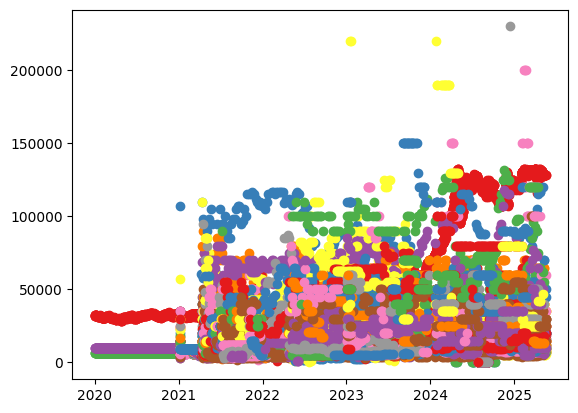

In [269]:
for idx, item in enumerate(filtered_df["Tên_mặt_hàng"].unique()):
    item_df = filtered_df[filtered_df["Tên_mặt_hàng"] == item]
    item_df = item_df.sort_values("Ngày")

    date = item_df["Ngày"]
    price = item_df["Giá"]

    plt.scatter(date, price, color=set3_colors[idx%9])

# Kiểm định ADF

In [ ]:
for item in filtered_df["Tên_mặt_hàng"].unique():
    item_df = 

# Label Encoding

In [270]:
filtered_df

,Ngày,Tên_mặt_hàng,Thị_trường,Loại_giá,Nguồn,Giá,Ngành_hàng
0,2020-01-01,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,32639.0,Cà phê
1,2020-01-01,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,32000.0,Cà phê
2,2020-01-02,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,32639.0,Cà phê
3,2020-01-02,Cà phê Robusta nhân xô,Lâm Đồng,Thương lái thu mua,CTV địa phương,32000.0,Cà phê
4,2020-01-03,Cà phê Robusta nhân xô,Đắk Lắk,Thương lái thu mua,CTV địa phương,32539.0,Cà phê
...,...,...,...,...,...,...,...
54143,2025-04-28,Mơ,Sơn La,Bán lẻ,CTV địa phương,25000.0,Rau quả
54144,2025-05-05,Mơ,Sơn La,Bán lẻ,CTV địa phương,25000.0,Rau quả
54145,2025-05-08,Mơ,Sơn La,Bán lẻ,CTV địa phương,25000.0,Rau quả
54146,2025-05-12,Mơ,Sơn La,Bán lẻ,CTV địa phương,25000.0,Rau quả
